## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline

## 2. Fetch the Dataset

In [2]:
df = pd.read_csv('Life Expectancy Data.csv')
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [3]:
df.head(10)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
5,Afghanistan,2010,Developing,58.8,279.0,74,0.01,79.679367,66.0,1989,...,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,0.448,9.2
6,Afghanistan,2009,Developing,58.6,281.0,77,0.01,56.762217,63.0,2861,...,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,0.434,8.9
7,Afghanistan,2008,Developing,58.1,287.0,80,0.03,25.873925,64.0,1599,...,64.0,8.33,64.0,0.1,373.361116,2729431.0,18.8,18.9,0.433,8.7
8,Afghanistan,2007,Developing,57.5,295.0,82,0.02,10.910156,63.0,1141,...,63.0,6.73,63.0,0.1,369.835796,26616792.0,19.0,19.1,0.415,8.4
9,Afghanistan,2006,Developing,57.3,295.0,84,0.03,17.171518,64.0,1990,...,58.0,7.43,58.0,0.1,272.563770,2589345.0,19.2,19.3,0.405,8.1


In [4]:
df.tail(10)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
2928,Zimbabwe,2009,Developing,50.0,587.0,30,4.64,1.040021,73.0,853,...,69.0,6.26,73.0,18.1,65.824121,1381599.0,7.5,7.4,0.419,9.9
2929,Zimbabwe,2008,Developing,48.2,632.0,30,3.56,20.843429,75.0,0,...,75.0,4.96,75.0,20.5,325.678573,13558469.0,7.8,7.8,0.421,9.7
2930,Zimbabwe,2007,Developing,46.6,67.0,29,3.88,29.814566,72.0,242,...,73.0,4.47,73.0,23.7,396.998217,1332999.0,8.2,8.2,0.414,9.6
2931,Zimbabwe,2006,Developing,45.4,7.0,28,4.57,34.262169,68.0,212,...,71.0,5.12,7.0,26.8,414.796232,13124267.0,8.6,8.6,0.408,9.5
2932,Zimbabwe,2005,Developing,44.6,717.0,28,4.14,8.717409,65.0,420,...,69.0,6.44,68.0,30.3,444.765750,129432.0,9.0,9.0,0.406,9.3
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8
2937,Zimbabwe,2000,Developing,46.0,665.0,24,1.68,0.000000,79.0,1483,...,78.0,7.10,78.0,43.5,547.358878,12222251.0,11.0,11.2,0.434,9.8


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [6]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

,0
Country,0
Year,0
Status,0
Life expectancy,10
Adult Mortality,10
infant deaths,0
Alcohol,194
percentage expenditure,0
Hepatitis B,553
Measles,0


## 3. Clean Column Names

Several column names have leading/trailing spaces (e.g. `'Life expectancy '`, `' BMI '`), which is a common issue with this dataset and will cause `KeyError`s later if not fixed now.

In [9]:
df.columns = df.columns.str.strip()
df.columns.tolist()

['Country',
 'Year',
 'Status',
 'Life expectancy',
 'Adult Mortality',
 'infant deaths',
 'Alcohol',
 'percentage expenditure',
 'Hepatitis B',
 'Measles',
 'BMI',
 'under-five deaths',
 'Polio',
 'Total expenditure',
 'Diphtheria',
 'HIV/AIDS',
 'GDP',
 'Population',
 'thinness  1-19 years',
 'thinness 5-9 years',
 'Income composition of resources',
 'Schooling']

## 4. Data Cleaning

Drop rows missing the target (`Life expectancy`) since those rows can't be used for training or evaluation at all. Other columns with missing values will be median-imputed later (after the train-test split, to avoid leakage).

In [10]:
important_cols = ['Country', 'Year', 'Life expectancy']
df_clean = df.dropna(subset=important_cols)
print(df_clean.shape)

(2928, 22)


In [11]:
df_clean.isnull().sum()

,0
Country,0
Year,0
Status,0
Life expectancy,0
Adult Mortality,0
infant deaths,0
Alcohol,193
percentage expenditure,0
Hepatitis B,553
Measles,0


In [12]:
df_clean.duplicated().sum()

np.int64(0)

In [13]:
df_clean['Status'].value_counts()

,count
Status,
Developing,2416
Developed,512


## 5. Exploratory Data Analysis (EDA)

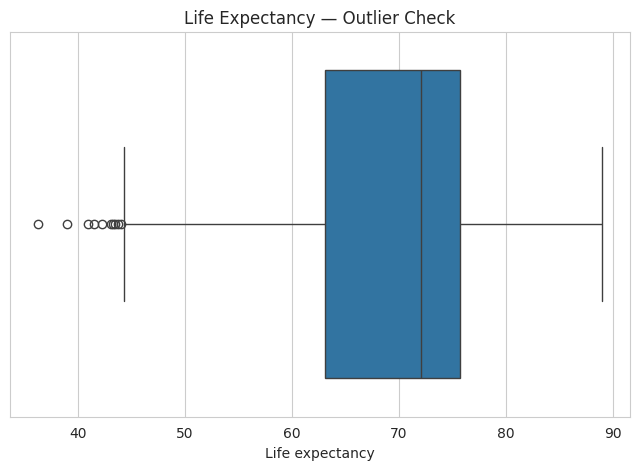

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Life expectancy', data=df_clean)
plt.title('Life Expectancy — Outlier Check')
plt.show()

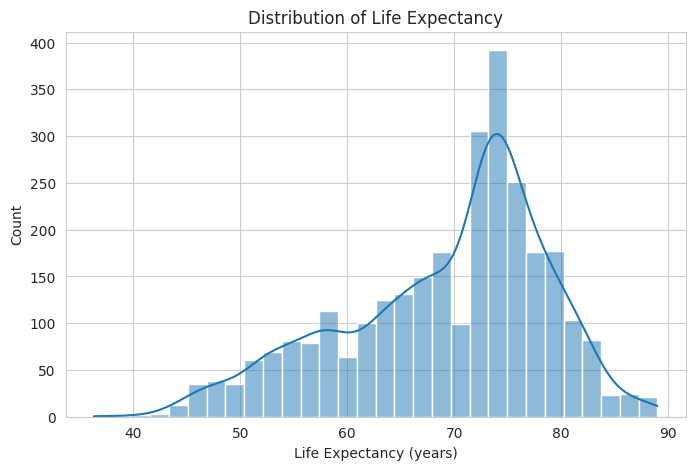

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Life expectancy'], kde=True, bins=30)
plt.title('Distribution of Life Expectancy')
plt.xlabel('Life Expectancy (years)')
plt.show()

Country
Japan          82.53750
Sweden         82.51875
Iceland        82.44375
Switzerland    82.33125
France         82.21875
Italy          82.18750
Spain          82.06875
Australia      81.81250
Norway         81.79375
Canada         81.68750
Name: Life expectancy, dtype: float64


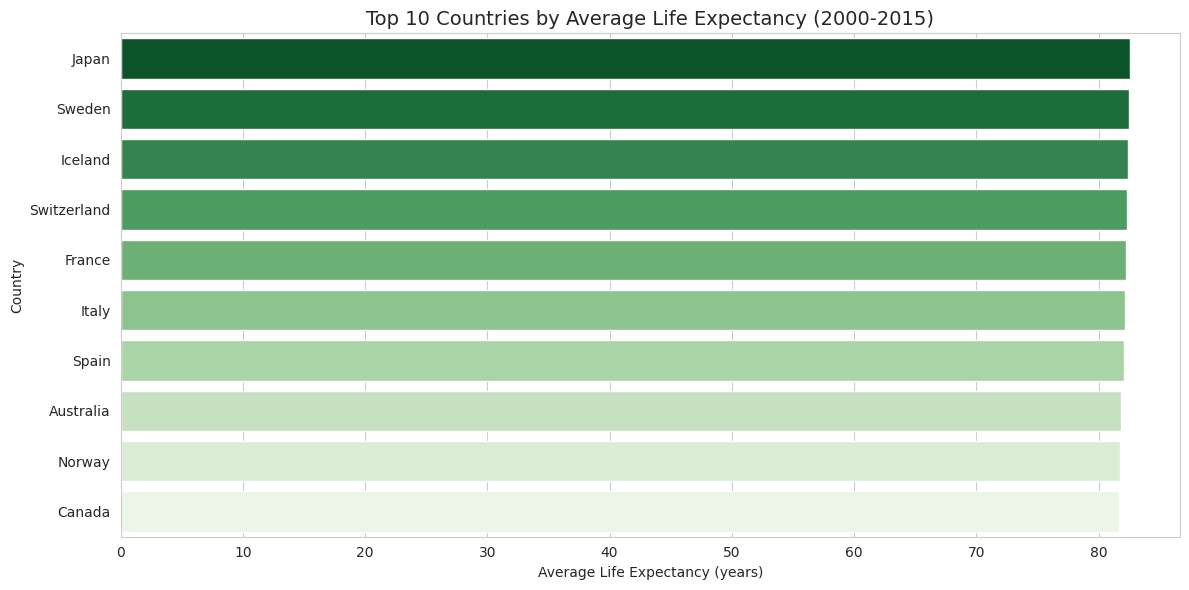

In [16]:
# Top 10 countries by average life expectancy
top10 = df_clean.groupby('Country')['Life expectancy'].mean().sort_values(ascending=False).head(10)
print(top10)

plt.figure(figsize=(12,6))
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette='Greens_r', legend=False)
plt.title('Top 10 Countries by Average Life Expectancy (2000-2015)', fontsize=14)
plt.xlabel('Average Life Expectancy (years)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

Country
Sierra Leone                46.11250
Central African Republic    48.51250
Lesotho                     48.78125
Angola                      49.01875
Malawi                      49.89375
Côte d'Ivoire               50.38750
Chad                        50.38750
Zimbabwe                    50.48750
Swaziland                   51.32500
Nigeria                     51.35625
Name: Life expectancy, dtype: float64


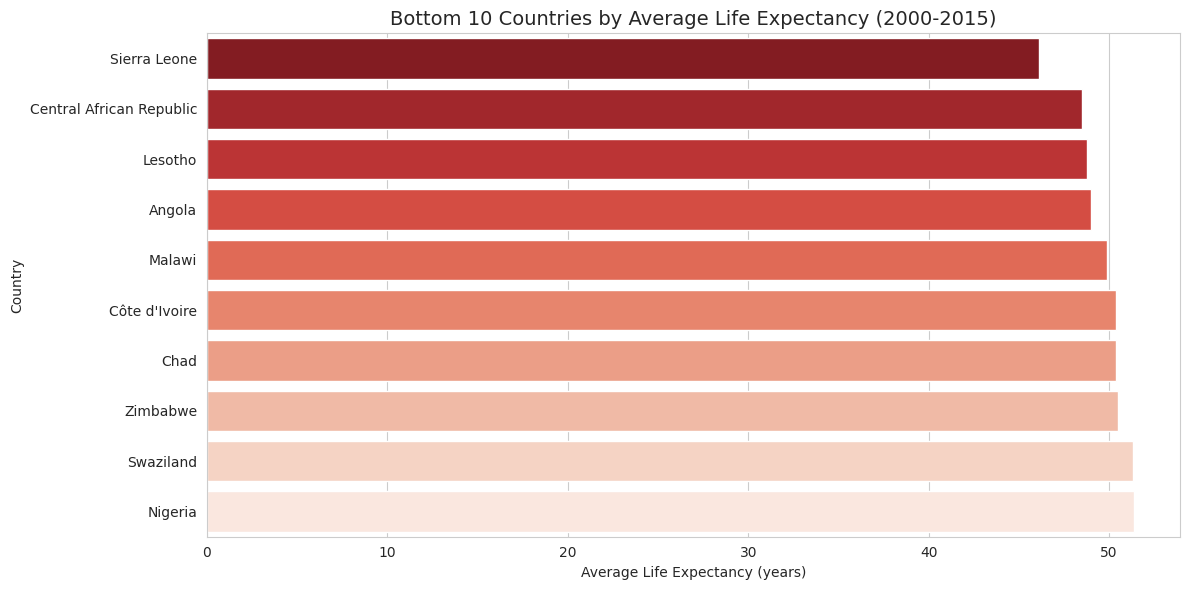

In [17]:
# Bottom 10 countries by average life expectancy
bottom10 = df_clean.groupby('Country')['Life expectancy'].mean().sort_values(ascending=True).head(10)
print(bottom10)

plt.figure(figsize=(12,6))
sns.barplot(x=bottom10.values, y=bottom10.index, hue=bottom10.index, palette='Reds_r', legend=False)
plt.title('Bottom 10 Countries by Average Life Expectancy (2000-2015)', fontsize=14)
plt.xlabel('Average Life Expectancy (years)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

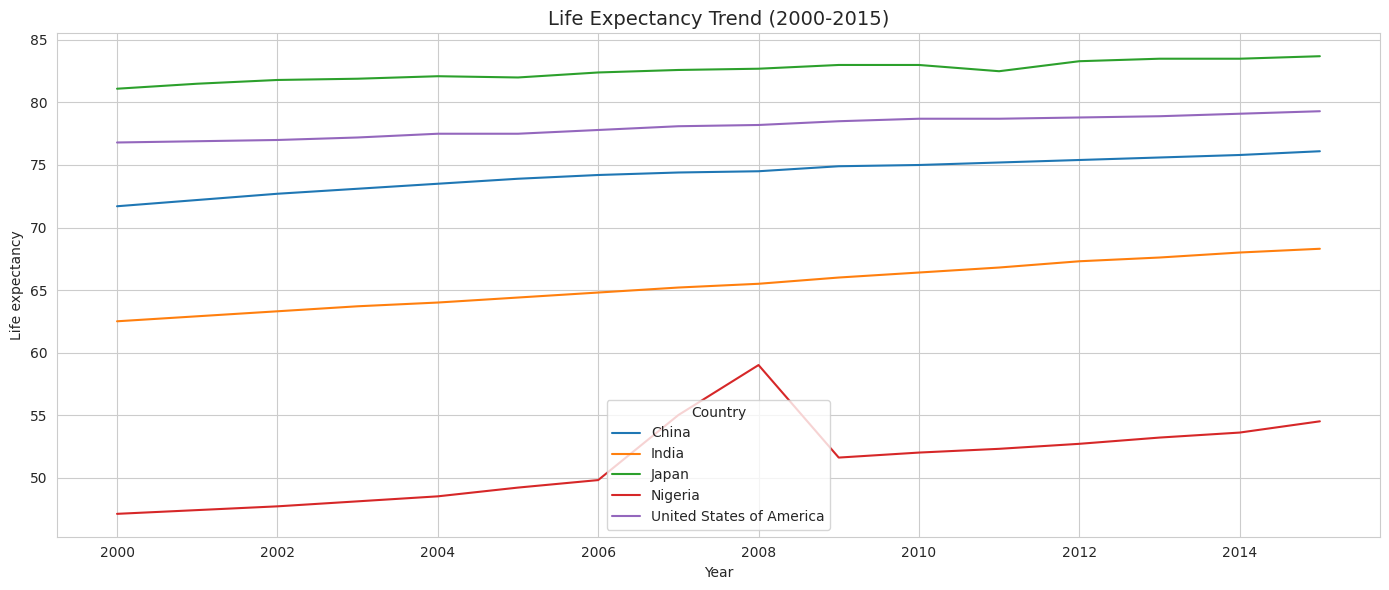

In [18]:
# Life expectancy trend for a few selected countries
selected_countries = ['India', 'United States of America', 'China', 'Nigeria', 'Japan']
df_sel = df_clean[df_clean['Country'].isin(selected_countries)]

plt.figure(figsize=(14,6))
sns.lineplot(data=df_sel, x='Year', y='Life expectancy', hue='Country')
plt.title('Life Expectancy Trend (2000-2015)', fontsize=14)
plt.tight_layout()
plt.show()

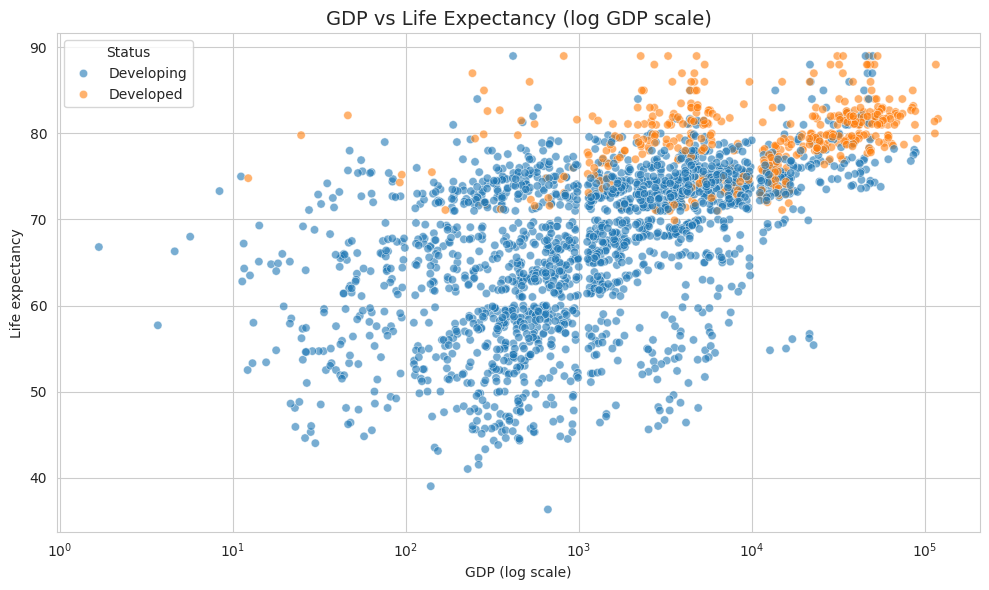

In [19]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, x='GDP', y='Life expectancy', hue='Status', alpha=0.6)
plt.xscale('log')
plt.title('GDP vs Life Expectancy (log GDP scale)', fontsize=14)
plt.xlabel('GDP (log scale)')
plt.tight_layout()
plt.show()

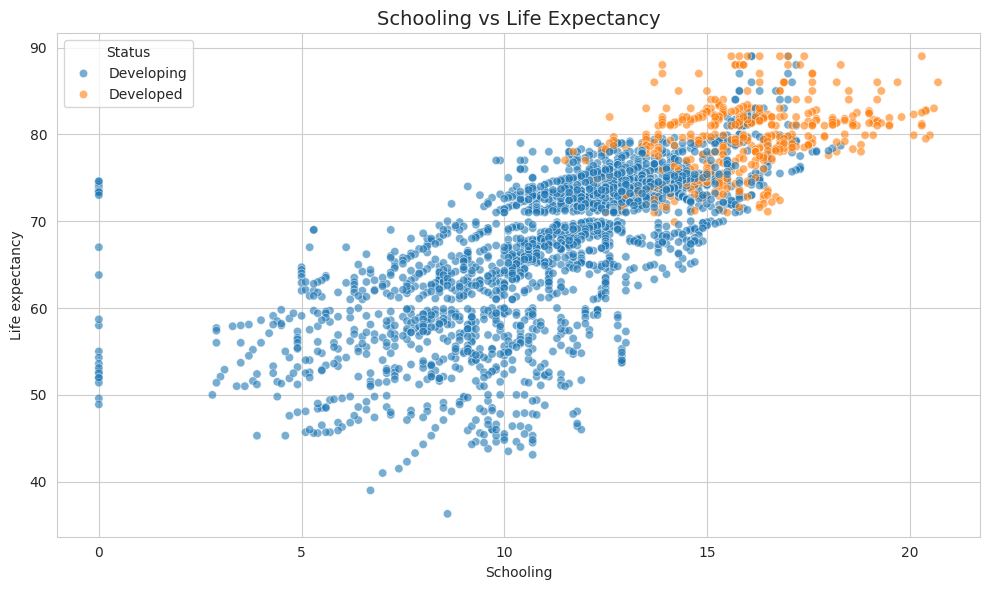

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, x='Schooling', y='Life expectancy', hue='Status', alpha=0.6)
plt.title('Schooling vs Life Expectancy', fontsize=14)
plt.tight_layout()
plt.show()

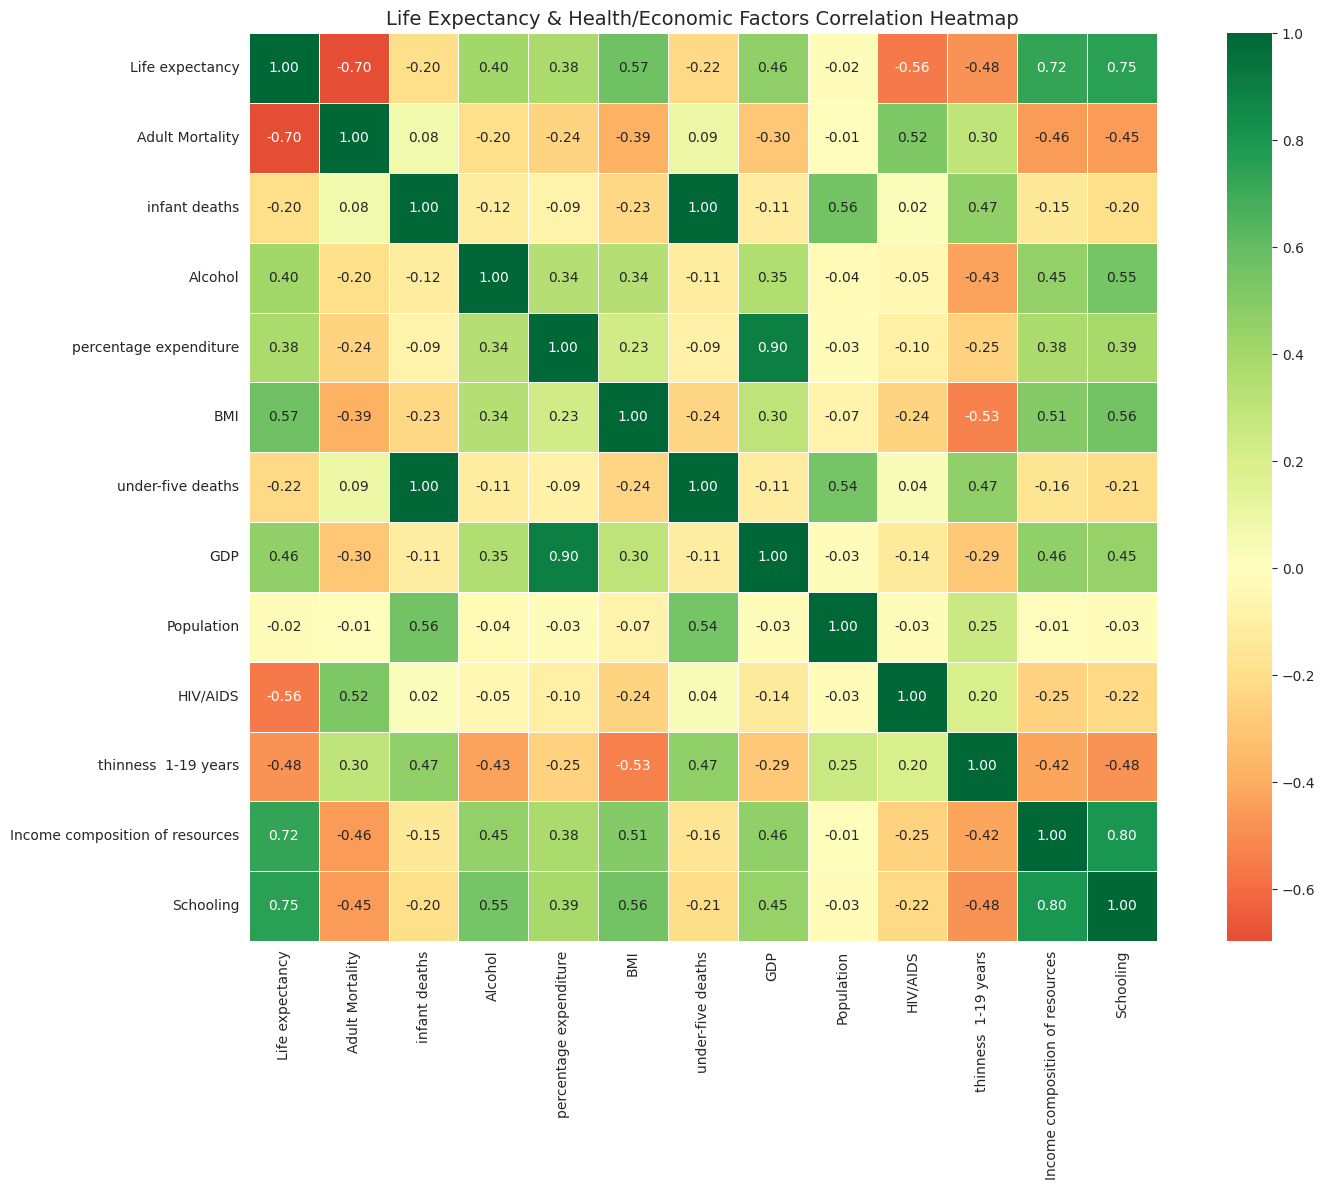

In [21]:
plt.figure(figsize=(16,12))

corr_cols = ['Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol',
             'percentage expenditure', 'BMI', 'under-five deaths', 'GDP',
             'Population', 'HIV/AIDS', 'thinness  1-19 years',
             'Income composition of resources', 'Schooling']

corr_matrix = df_clean[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5)
plt.title('Life Expectancy & Health/Economic Factors Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

**Observation:** `Schooling` and `Income composition of resources` show a strong positive correlation with life expectancy, while `Adult Mortality` and `HIV/AIDS` show a strong negative correlation. `Status` (Developed vs Developing) also visibly separates the GDP-vs-life-expectancy relationship.

## 6. Encode Categorical Variable (`Status`)

In [22]:
df_clean = df_clean.copy()
df_clean['Status'] = df_clean['Status'].map({'Developing': 0, 'Developed': 1})
df_clean[['Status']].value_counts()

,count
Status,
0,2416
1,512


## 7. Define Features (X) and Target (y)

`Country` is dropped from the model features (193 unique categories — too high-cardinality to one-hot encode meaningfully for a model of this size, similar to dropping high-cardinality geography columns in the earlier heart attack project). `Year` is kept as a numeric feature.

In [23]:
X = df_clean.drop(columns=['Country', 'Life expectancy'])
y = df_clean['Life expectancy']

print("Features:", list(X.columns))
print("X shape:", X.shape, "| y shape:", y.shape)

Features: ['Year', 'Status', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']
X shape: (2928, 20) | y shape: (2928,)


## 8. Train-Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (2342, 20) | Test size: (586, 20)


## 9. Handle Remaining Missing Values

Several features (e.g. `GDP`, `Population`, `Hepatitis B`) still have missing values. These are filled with the **training set's** median, and the same training median is applied to the test set — this avoids data leakage (the test set should never influence imputation values).

In [25]:
train_medians = X_train.median()

X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("Remaining missing in X_train:", X_train.isnull().sum().sum())
print("Remaining missing in X_test :", X_test.isnull().sum().sum())

Remaining missing in X_train: 0
Remaining missing in X_test : 0


## 10. Linear Regression (Baseline)

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"MSE  : {mse_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R2   : {r2_lr:.4f}")

Linear Regression Results:
MSE  : 15.6142
RMSE : 3.9515
R2   : 0.8195


## 11. Decision Tree Regressor

In [27]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
train_pred_dt = dt_model.predict(X_train)

r2_train_dt = r2_score(y_train, train_pred_dt)
r2_test_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results (unpruned):")
print(f"Training R2 : {r2_train_dt:.4f}")
print(f"Testing R2  : {r2_test_dt:.4f}")
print(f"Difference  : {abs(r2_train_dt - r2_test_dt):.4f}")

Decision Tree Results (unpruned):
Training R2 : 1.0000
Testing R2  : 0.9213
Difference  : 0.0787


**Observation:** A large gap between training R² and testing R² indicates overfitting — the unpruned tree has memorized the training data. Pruning (limiting `max_depth` and `min_samples_split`) should reduce this gap, just as it did for the Decision Tree Classifier in the CO2 project.

In [28]:
dt_model_pruned = DecisionTreeRegressor(
    random_state=42,
    max_depth=6,
    min_samples_split=10
)
dt_model_pruned.fit(X_train, y_train)
y_pred_pruned = dt_model_pruned.predict(X_test)
train_pred_pruned = dt_model_pruned.predict(X_train)

r2_train_pruned = r2_score(y_train, train_pred_pruned)
r2_test_pruned = r2_score(y_test, y_pred_pruned)

print("Decision Tree Results (pruned):")
print(f"Training R2 : {r2_train_pruned:.4f}")
print(f"Testing R2  : {r2_test_pruned:.4f}")
print(f"Difference  : {abs(r2_train_pruned - r2_test_pruned):.4f}")

Decision Tree Results (pruned):
Training R2 : 0.9402
Testing R2  : 0.9199
Difference  : 0.0203


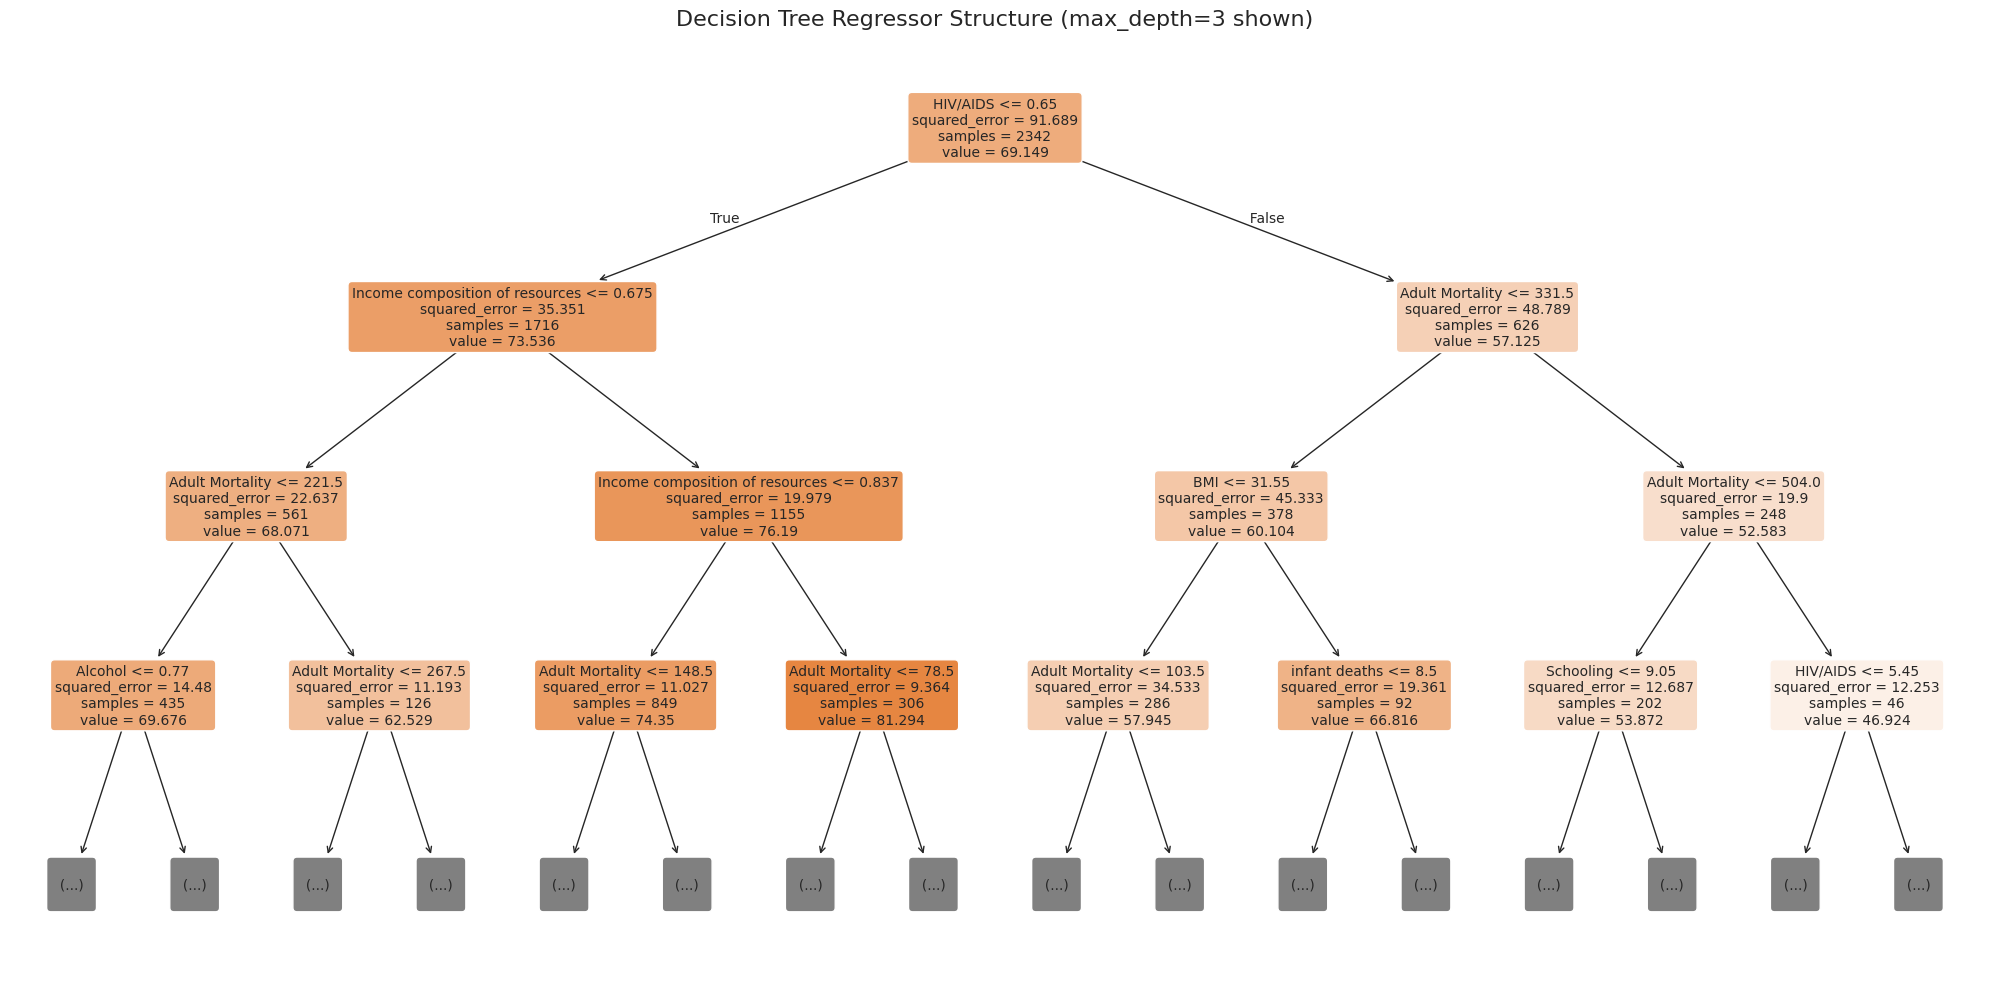

In [29]:
plt.figure(figsize=(20,10))
plot_tree(dt_model_pruned,
          feature_names=X.columns.tolist(),
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)  # only top 3 levels shown, otherwise too large to read

plt.title('Decision Tree Regressor Structure (max_depth=3 shown)', fontsize=16)
plt.tight_layout()
plt.show()

## 12. Random Forest Regressor

This mirrors exactly how the Random Forest Classifier was built in the CO2 project (`n_estimators=100`, `random_state=42`), but using `RandomForestRegressor` and regression metrics (MSE/RMSE/R²) instead of accuracy/classification_report.

In [30]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
train_pred_rf = rf_model.predict(X_train)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_train_rf = r2_score(y_train, train_pred_rf)
r2_test_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"Training R2 : {r2_train_rf:.4f}")
print(f"Testing R2  : {r2_test_rf:.4f}")
print(f"Difference  : {abs(r2_train_rf - r2_test_rf):.4f}")
print(f"Testing RMSE: {rmse_rf:.4f}")

Random Forest Results:
Training R2 : 0.9946
Testing R2  : 0.9672
Difference  : 0.0274
Testing RMSE: 1.6849


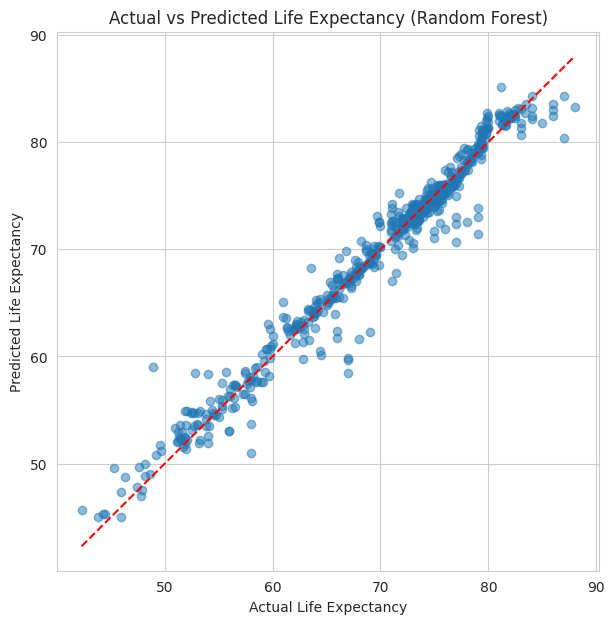

In [31]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title('Actual vs Predicted Life Expectancy (Random Forest)')
plt.show()

## 13. Model Comparison

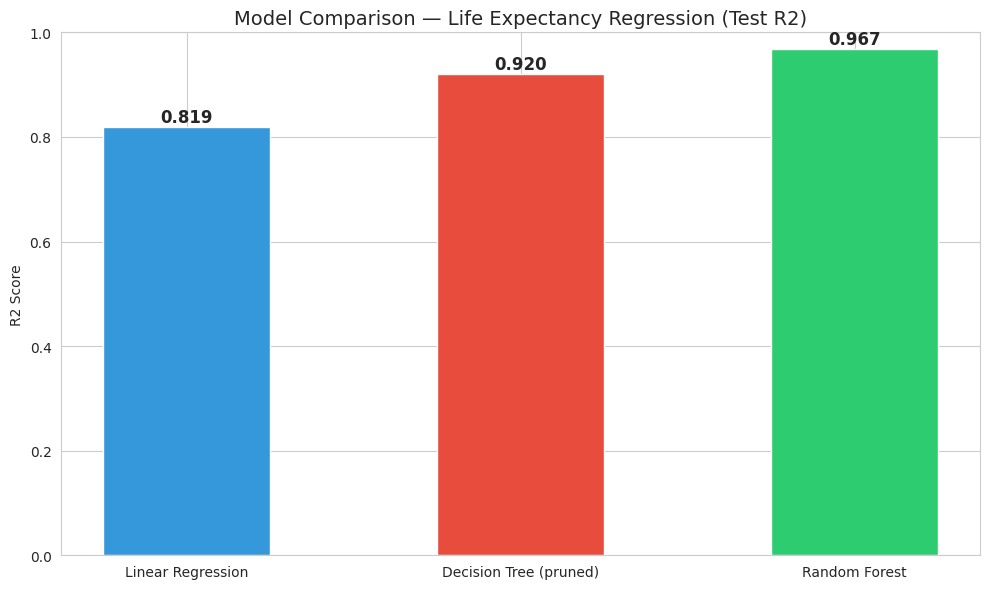

In [32]:
models = ['Linear Regression', 'Decision Tree (pruned)', 'Random Forest']
r2_scores = [r2_lr, r2_test_pruned, r2_test_rf]

plt.figure(figsize=(10,6))
bars = plt.bar(models, r2_scores, color=['#3498db', '#e74c3c', '#2ecc71'], width=0.5)
plt.ylim(0, 1.0)
plt.title('Model Comparison — Life Expectancy Regression (Test R2)', fontsize=14)
plt.ylabel('R2 Score')

for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
              f'{score:.3f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 14. Feature Importance (Random Forest)

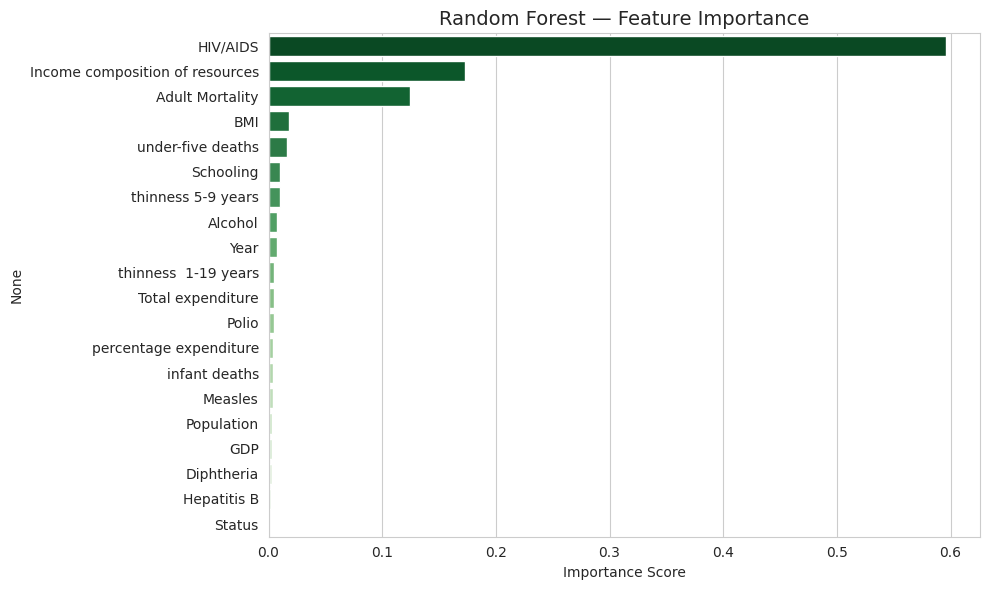

,0
HIV/AIDS,0.596072
Income composition of resources,0.172460
Adult Mortality,0.124792
BMI,0.017628
under-five deaths,0.016518
Schooling,0.010185
thinness 5-9 years,0.009744
Alcohol,0.007622
Year,0.007196
thinness 1-19 years,0.005235


In [33]:
feat_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_importance.values, y=feat_importance.index,
            hue=feat_importance.index, palette='Greens_r', legend=False)
plt.title('Random Forest — Feature Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

feat_importance